In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# Directories: works whether the notebook is launched from repo root or notebooks/.
CWD = Path.cwd().resolve()
REPO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
BASE_CRM = REPO_ROOT / "results" / "crm"
BASE_RBF = REPO_ROOT / "results" / "rbf"

FIG_DIR = REPO_ROOT / "FINAL" / "notebooks" / "plots" / "comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig_dir = FIG_DIR

# Helper to get subdirectories assuming identical CRM/RBF result structure.
def get_dirs(base_path):
    return {
        "solid": base_path / "solid" / "v18_reissner_mindlin_plate",
        "fluid": base_path / "fluid",
        "coupling": base_path / "coupling",
    }

dirs_crm = get_dirs(BASE_CRM)
dirs_rbf = get_dirs(BASE_RBF)

# Plot settings
plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm", "font.size": 10,
    "axes.labelsize": 10, "axes.titlesize": 10, "legend.fontsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "lines.linewidth": 1.2,
    "axes.linewidth": 0.8, "figure.dpi": 300, "savefig.bbox": "tight",
})

def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing required result file: {path}")
    return path

def infer_dt_from_solid(solid_df):
    times = solid_df["time"].to_numpy(dtype=float)
    if len(times) < 2:
        return np.nan
    diffs = np.diff(times)
    diffs = diffs[np.isfinite(diffs) & (diffs > 0.0)]
    return float(np.median(diffs)) if len(diffs) else np.nan

def diagnostic_time(df, solid_df=None):
    if "time" in df.columns:
        times = df["time"].to_numpy(dtype=float)
        if np.isfinite(times).any():
            return times
    if solid_df is None:
        raise ValueError("Cannot infer diagnostic time without a time column or solid diagnostics.")
    return df["step"].to_numpy(dtype=float) * infer_dt_from_solid(solid_df)

def time_from_steps(steps, solid_df):
    return np.asarray(steps, dtype=float) * infer_dt_from_solid(solid_df)

def require_columns(df, columns, label):
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(
            f"{label} is missing {missing}. Rerun the CRM/RBF simulations after the "
            "transfer-diagnostic code changes so coupling_history.csv contains these columns."
        )

# Load the core diagnostic files for BOTH cases.
solid_crm = pd.read_csv(require_file(dirs_crm["solid"] / "solid_v18_diagnostics.csv"))
fluid_coupling_crm = pd.read_csv(require_file(dirs_crm["fluid"] / "static_airfoil_spanwise_coupling_diagnostics.csv"))
coupling_crm = pd.read_csv(require_file(dirs_crm["coupling"] / "coupling_history.csv"))

solid_rbf = pd.read_csv(require_file(dirs_rbf["solid"] / "solid_v18_diagnostics.csv"))
fluid_coupling_rbf = pd.read_csv(require_file(dirs_rbf["fluid"] / "static_airfoil_spanwise_coupling_diagnostics.csv"))
coupling_rbf = pd.read_csv(require_file(dirs_rbf["coupling"] / "coupling_history.csv"))

print(f"CRM data root: {BASE_CRM}")
print(f"RBF data root: {BASE_RBF}")
print("Both diagnostic datasets loaded successfully.")



CRM data root: /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/crm
RBF data root: /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/rbf
Both diagnostic datasets loaded successfully.


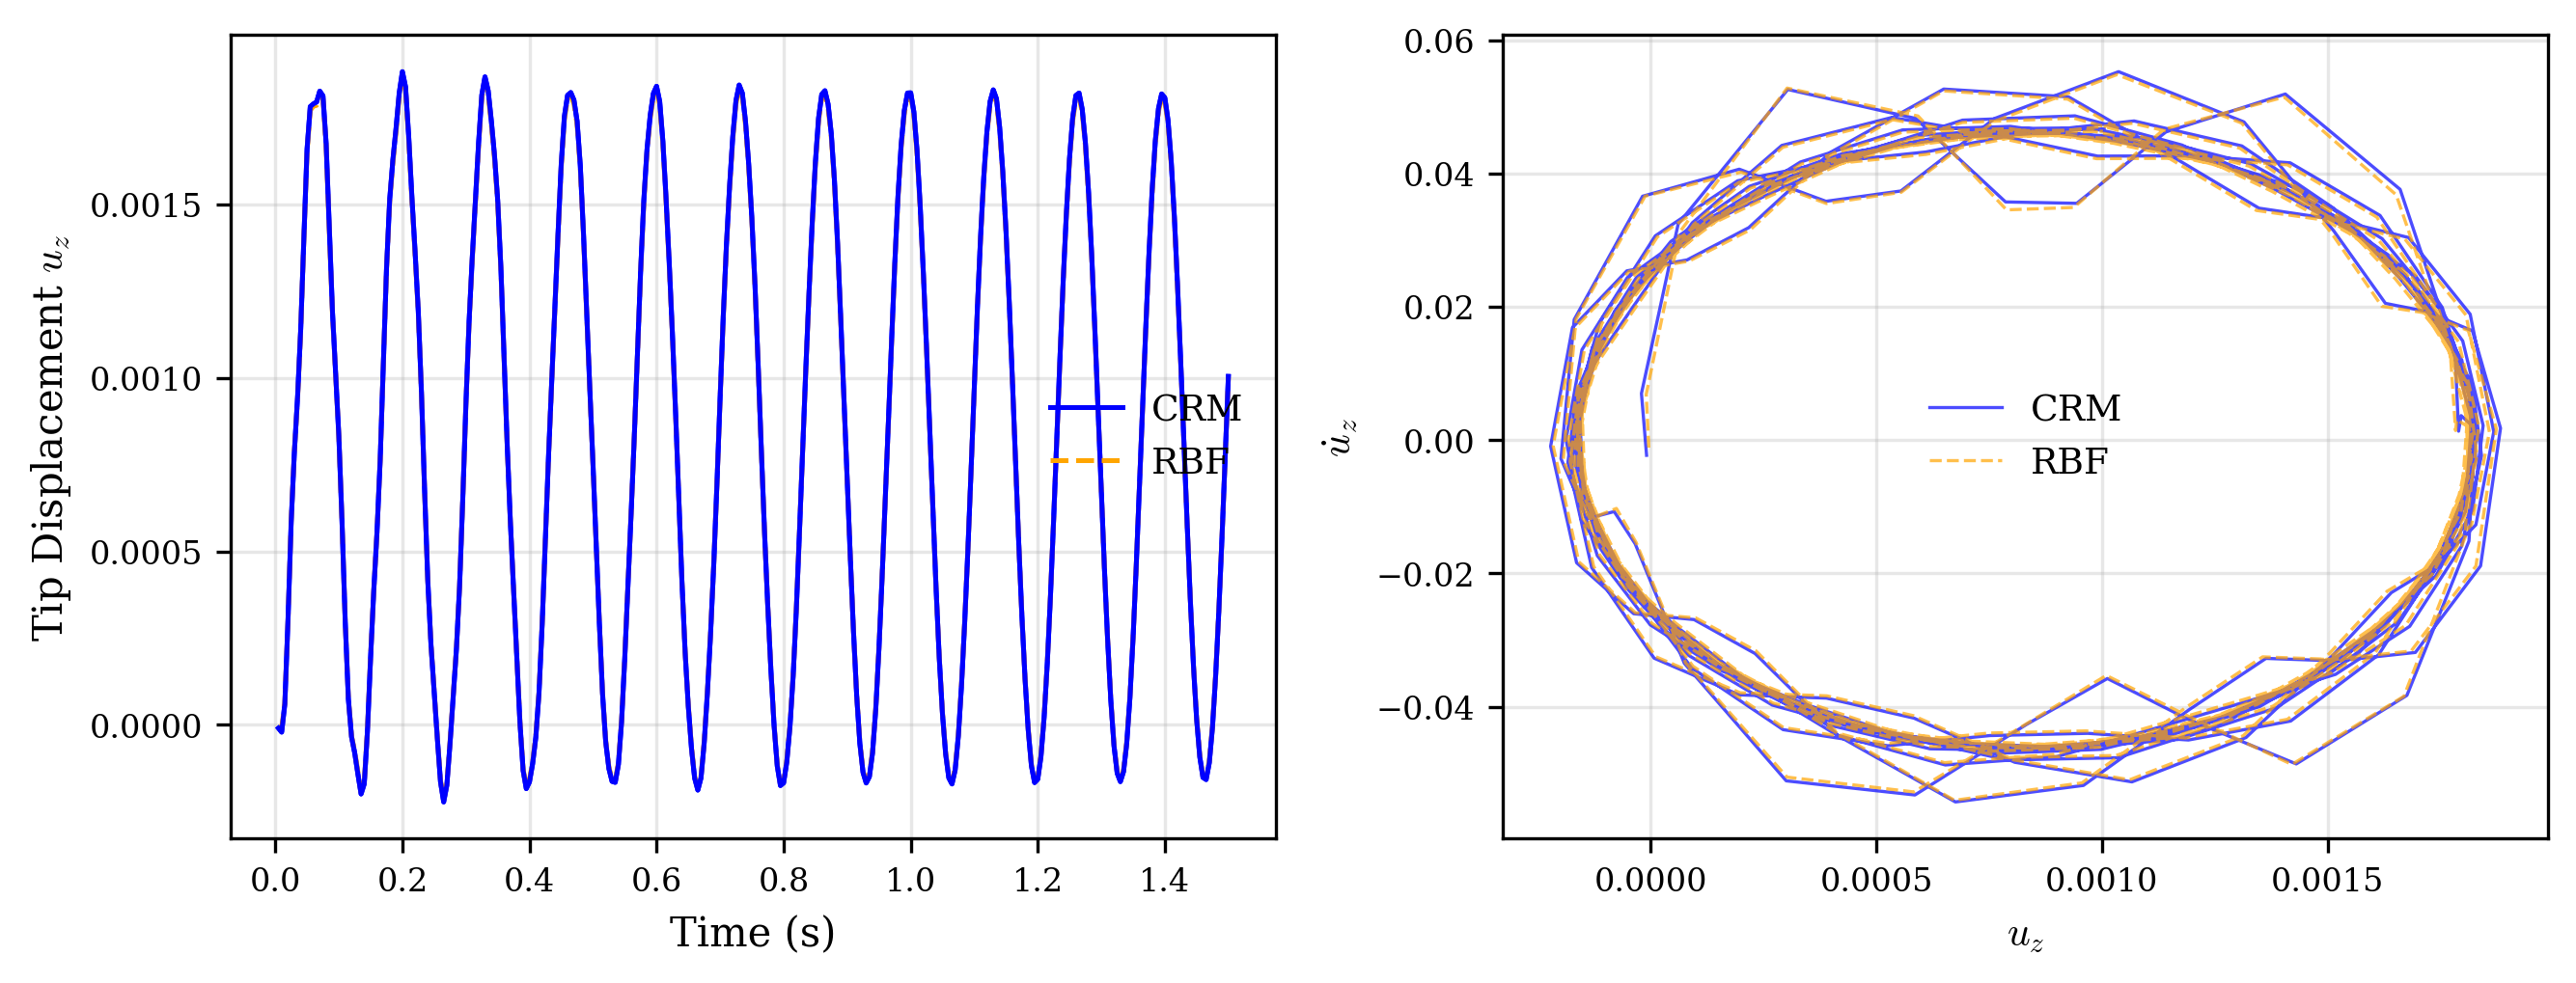

In [2]:
# Extract CRM data
time_crm = solid_crm['time'].values
u_tip_crm = solid_crm['u_tip'].values
v_tip_crm = np.gradient(u_tip_crm, time_crm)

# Extract RBF data
time_rbf = solid_rbf['time'].values
u_tip_rbf = solid_rbf['u_tip'].values
v_tip_rbf = np.gradient(u_tip_rbf, time_rbf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# Plot 1: Displacement Time History
ax1.plot(time_crm, u_tip_crm, color='b', linestyle='-', label='CRM')
ax1.plot(time_rbf, u_tip_rbf, color='orange', linestyle='--', label='RBF')
ax1.set_xlabel(r"Time (s)")
ax1.set_ylabel(r"Tip Displacement $u_z$")
ax1.grid(True, alpha=0.3)
# plt.xlim(4,5)
ax1.legend(frameon=False)

# Plot 2: Phase Space
ax1.plot(time_crm, u_tip_crm, color='b', linestyle='-', label='CRM')
ax2.plot(u_tip_crm, v_tip_crm, color='b', linestyle='-', linewidth=0.8, alpha=0.7, label='CRM')
ax2.plot(u_tip_rbf, v_tip_rbf, color='orange', linestyle='--', linewidth=0.8, alpha=0.7, label='RBF')
ax2.set_xlabel(r"$u_z$")
ax2.set_ylabel(r"$\dot{u}_z$")
ax2.grid(True, alpha=0.3)
# plt.xlim(4,5)
ax2.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_kinematics.pdf")
plt.show()


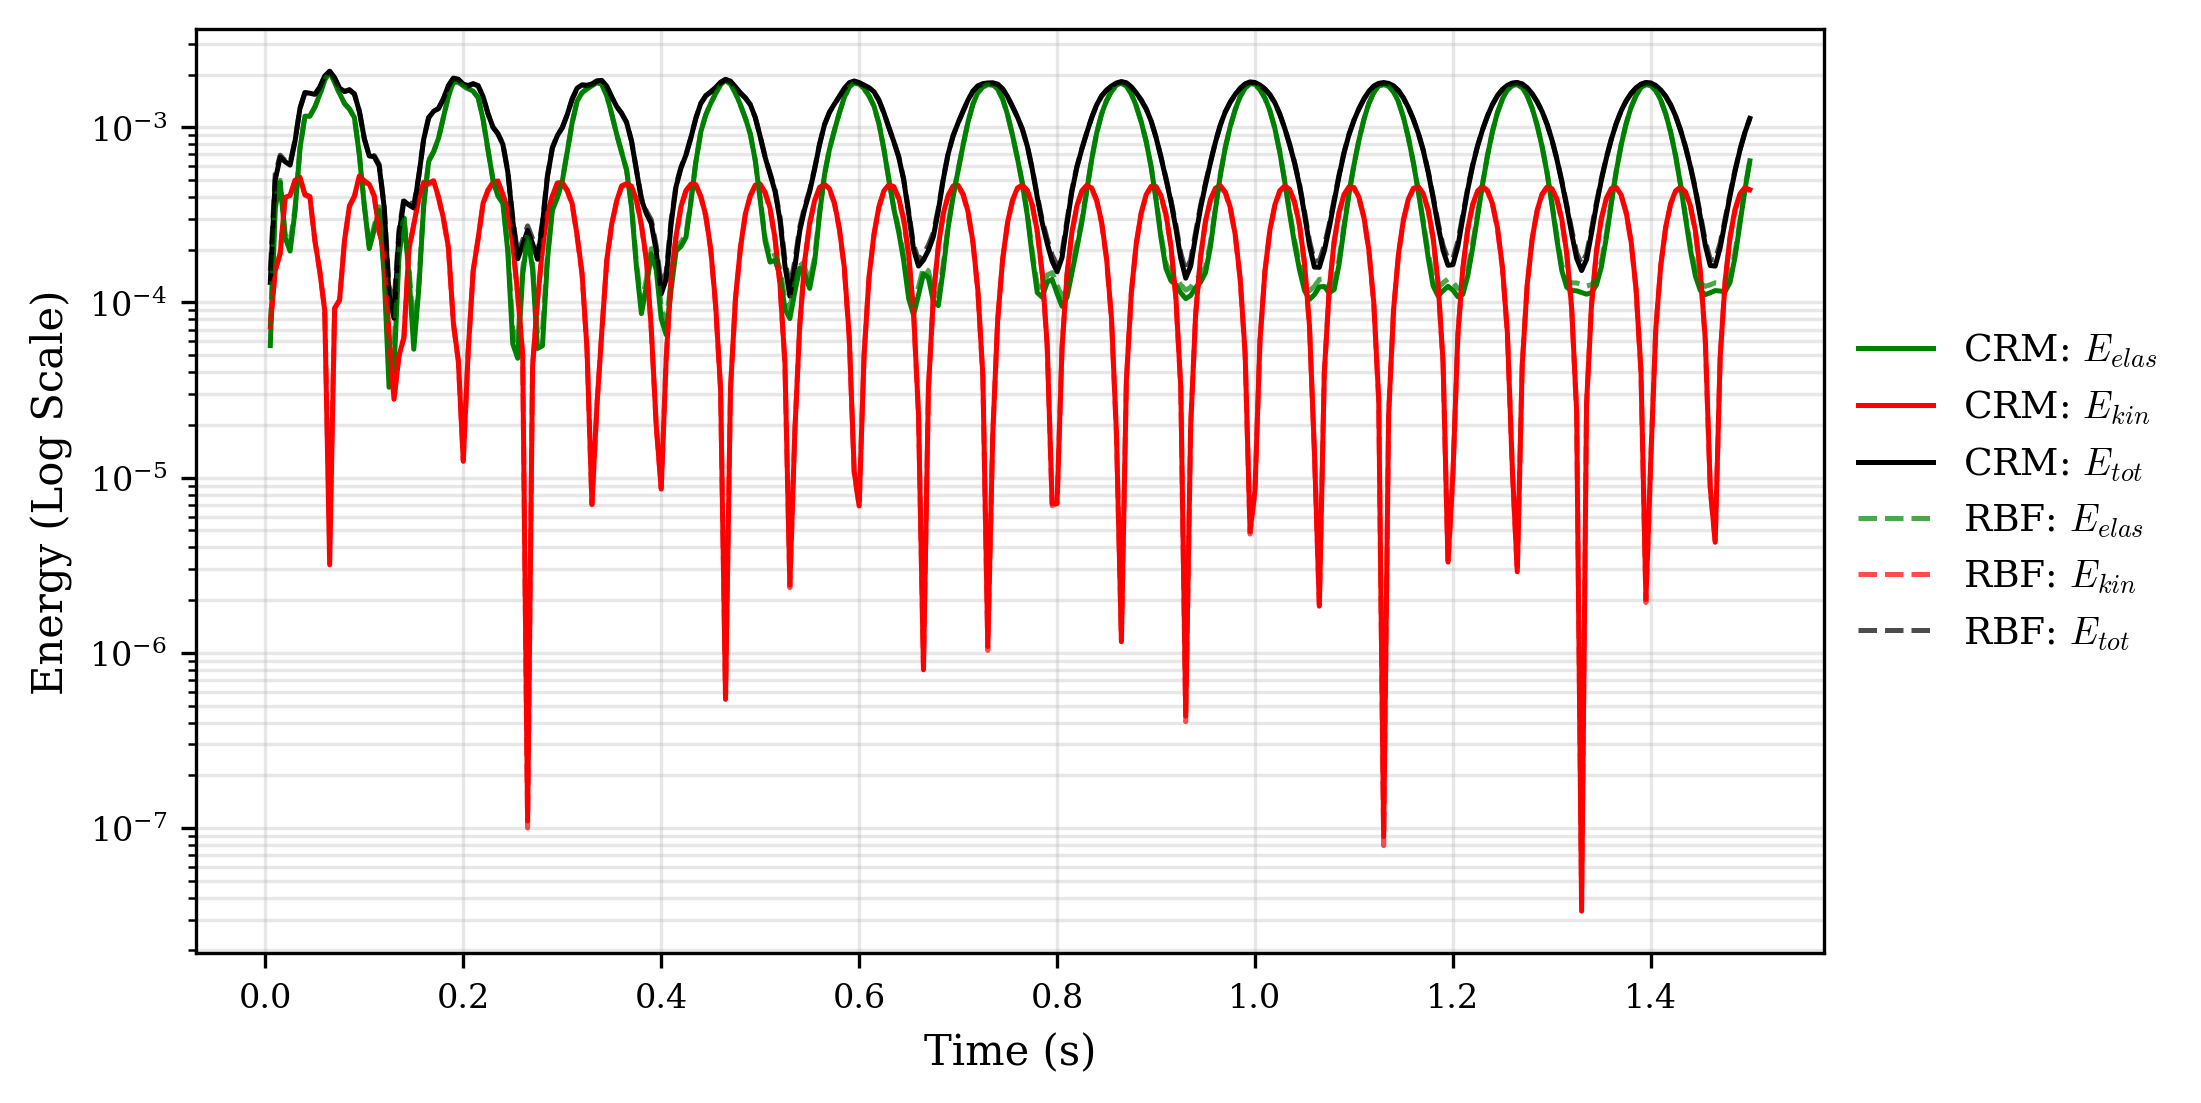

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

# Plot CRM (Solid lines)
ax.semilogy(time_crm, solid_crm['E_elas'], color='g', linestyle='-', label=r"CRM: $E_{elas}$")
ax.semilogy(time_crm, solid_crm['E_kin'], color='r', linestyle='-', label=r"CRM: $E_{kin}$")
ax.semilogy(time_crm, solid_crm['E_tot'], color='k', linestyle='-', label=r"CRM: $E_{tot}$")

# Plot RBF (Dashed lines)
ax.semilogy(time_rbf, solid_rbf['E_elas'], color='g', linestyle='--', alpha=0.7, label=r"RBF: $E_{elas}$")
ax.semilogy(time_rbf, solid_rbf['E_kin'], color='r', linestyle='--', alpha=0.7, label=r"RBF: $E_{kin}$")
ax.semilogy(time_rbf, solid_rbf['E_tot'], color='k', linestyle='--', alpha=0.7, label=r"RBF: $E_{tot}$")

ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"Energy (Log Scale)")
ax.grid(True, which="both", alpha=0.3)

# Place legend outside to avoid cluttering the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

fig.savefig(FIG_DIR / "comparison_energy_log.pdf", bbox_inches='tight')
plt.show()


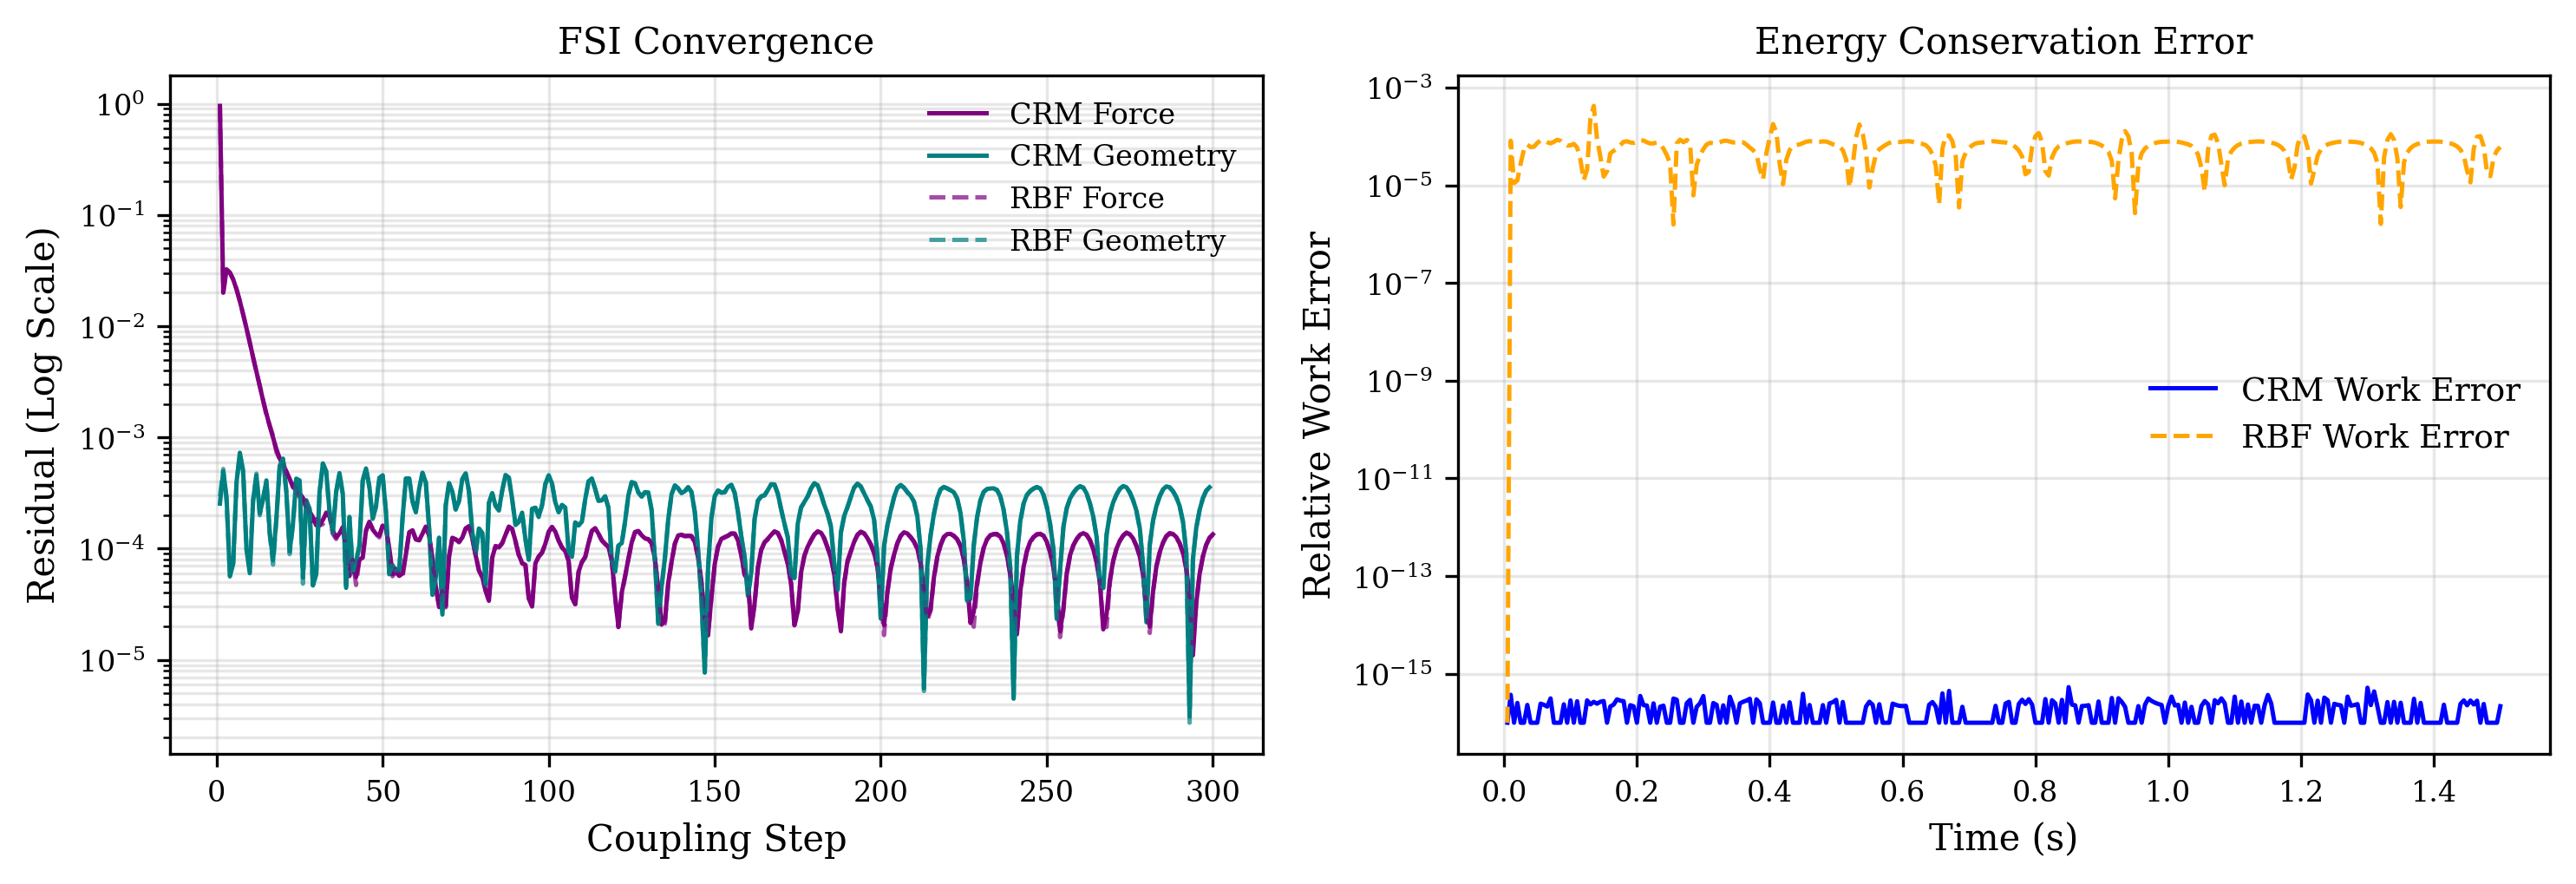

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

# Plot 1: FSI Coupling Residuals
ax1.semilogy(fluid_coupling_crm['step'], fluid_coupling_crm['force_residual'], color='purple', linestyle='-', label='CRM Force')
ax1.semilogy(fluid_coupling_crm['step'], fluid_coupling_crm['geometry_residual'], color='teal', linestyle='-', label='CRM Geometry')

ax1.semilogy(fluid_coupling_rbf['step'], fluid_coupling_rbf['force_residual'], color='purple', linestyle='--', alpha=0.7, label='RBF Force')
ax1.semilogy(fluid_coupling_rbf['step'], fluid_coupling_rbf['geometry_residual'], color='teal', linestyle='--', alpha=0.7, label='RBF Geometry')

ax1.set_xlabel(r"Coupling Step")
ax1.set_ylabel(r"Residual (Log Scale)")
ax1.set_title("FSI Convergence")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(fontsize=8, frameon=False)

# Plot 2: Solid Solver Work Error
ax2.semilogy(time_crm, solid_crm['work_rel_error'] + 1e-16, color='b', linestyle='-', label='CRM Work Error')
ax2.semilogy(time_rbf, solid_rbf['work_rel_error'] + 1e-16, color='orange', linestyle='--', label='RBF Work Error')

ax2.set_xlabel(r"Time (s)")
ax2.set_ylabel(r"Relative Work Error")
ax2.set_title("Energy Conservation Error")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_solver_diagnostics_log.pdf")
plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


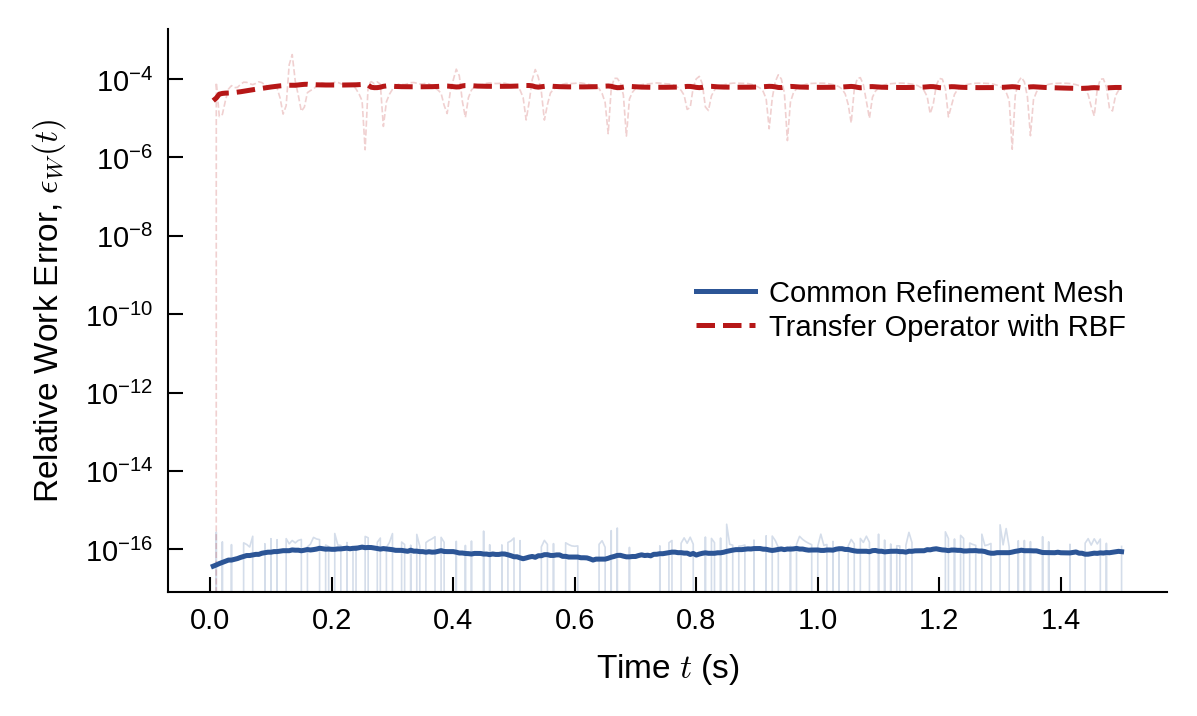

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

COLOR_CRM_WORK = "#2C5596"
COLOR_RBF_WORK = "#B61717"


# ------------------------------------------------------------
# Moving-average function
# ------------------------------------------------------------

def moving_average(data, window_size=50):
    data = np.asarray(data, dtype=float)

    if window_size <= 1:
        return data.copy()

    window_size = min(window_size, len(data))

    pad_left = window_size // 2
    pad_right = window_size - 1 - pad_left

    padded = np.pad(
        data,
        (pad_left, pad_right),
        mode="edge"
    )

    kernel = np.ones(window_size) / window_size

    return np.convolve(
        padded,
        kernel,
        mode="valid"
    )


# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

WINDOW = 50

crm_work = np.asarray(
    solid_crm["work_rel_error"],
    dtype=float
)

rbf_work = np.asarray(
    solid_rbf["work_rel_error"],
    dtype=float
)

crm_work_ma = moving_average(crm_work, WINDOW)
rbf_work_ma = moving_average(rbf_work, WINDOW)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)

ax.set_yscale("log")


# ------------------------------------------------------------
# Raw work-conservation error
# ------------------------------------------------------------

ax.plot(
    time_crm,
    crm_work,
    color=COLOR_CRM_WORK,
    linestyle="-",
    linewidth=0.4,
    alpha=0.20,
    zorder=1
)

ax.plot(
    time_rbf,
    rbf_work,
    color=COLOR_RBF_WORK,
    linestyle="--",
    linewidth=0.4,
    alpha=0.20,
    zorder=1
)


# ------------------------------------------------------------
# Moving averages
# ------------------------------------------------------------

h_crm_err, = ax.plot(
    time_crm,
    crm_work_ma,
    color=COLOR_CRM_WORK,
    linestyle="-",
    linewidth=1.2,
    alpha=1.0,
    zorder=2
)

h_rbf_err, = ax.plot(
    time_rbf,
    rbf_work_ma,
    color=COLOR_RBF_WORK,
    linestyle="--",
    linewidth=1.2,
    alpha=1.0,
    zorder=2
)


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    r"Time $t$ (s)",
    labelpad=4
)

ax.set_ylabel(
    r"Relative Work Error, $\epsilon_W(t)$",
    labelpad=4
)

# ax.set_ylim(1e-16, 1e-1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    handles=[h_crm_err, h_rbf_err],
    labels=[
        "Common Refinement Mesh",
        "Transfer Operator with RBF"
    ],
    frameon=False,
    loc="best",
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=1.0
)


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

fig.tight_layout()

fig.savefig(
    "work_cons.pdf",
    bbox_inches="tight",
    transparent=True
)

plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


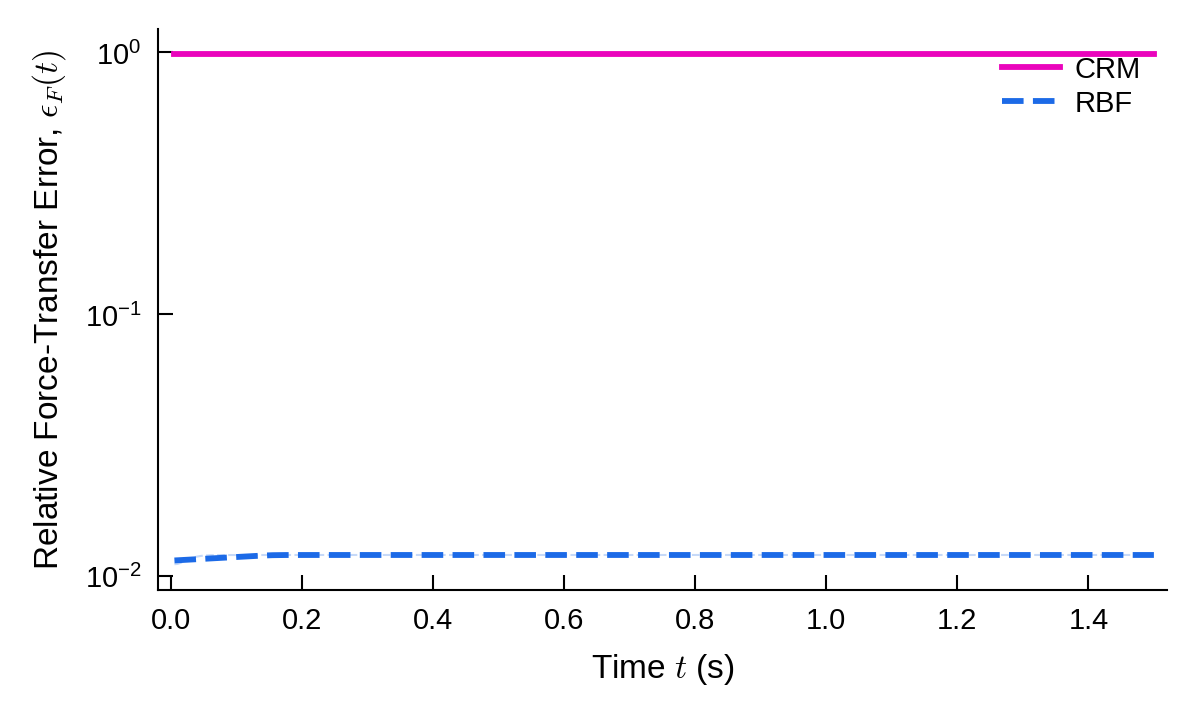

In [14]:
# ============================================================
# Relative Interface-Transfer Errors
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Colour scheme — same as before
# ------------------------------------------------------------

COLOR_CRM_FORCE = "#EA04BC"       # Magenta
COLOR_CRM_GEOMETRY = "#1FB205"    # Green
COLOR_RBF_FORCE = "#1C6AE7"       # Blue
COLOR_RBF_GEOMETRY = "#E01717"    # Red


# ------------------------------------------------------------
# Physical time directly from coupling_history.csv
# ------------------------------------------------------------

time_coupling_crm = coupling_crm["time"].to_numpy(dtype=float)
time_coupling_rbf = coupling_rbf["time"].to_numpy(dtype=float)


# ------------------------------------------------------------
# Moving average
# ------------------------------------------------------------

def moving_average(data, window_size=50):
    data = np.asarray(data, dtype=float)

    if window_size <= 1:
        return data.copy()

    window_size = min(window_size, len(data))

    pad_left = window_size // 2
    pad_right = window_size - 1 - pad_left

    padded = np.pad(
        data,
        (pad_left, pad_right),
        mode="edge"
    )

    kernel = np.ones(window_size) / window_size

    return np.convolve(padded, kernel, mode="valid")


WINDOW = 50


# ------------------------------------------------------------
# Extract the saved instantaneous transfer errors
# ------------------------------------------------------------

crm_force_error = coupling_crm[
    "force_transfer_relative_error"
].to_numpy(dtype=float)

rbf_force_error = coupling_rbf[
    "force_transfer_relative_error"
].to_numpy(dtype=float)

crm_geometry_error = coupling_crm[
    "geometry_transfer_relative_error"
].to_numpy(dtype=float)

rbf_geometry_error = coupling_rbf[
    "geometry_transfer_relative_error"
].to_numpy(dtype=float)


# ------------------------------------------------------------
# Moving averages
# ------------------------------------------------------------

crm_force_ma = moving_average(crm_force_error, WINDOW)
rbf_force_ma = moving_average(rbf_force_error, WINDOW)

crm_geometry_ma = moving_average(crm_geometry_error, WINDOW)
rbf_geometry_ma = moving_average(rbf_geometry_error, WINDOW)


# ============================================================
# FIGURE 1 — Relative Force-Transfer Error
# ============================================================

fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)
ax.set_yscale("log")

# ------------------------------------------------------------
# Raw force-transfer errors
# ------------------------------------------------------------

ax.plot(
    time_coupling_crm,
    crm_force_error,
    color=COLOR_CRM_FORCE,
    linestyle="-",
    linewidth=0.5,
    alpha=0.25,
    zorder=1
)

ax.plot(
    time_coupling_rbf,
    rbf_force_error,
    color=COLOR_RBF_FORCE,
    linestyle="--",
    linewidth=0.5,
    alpha=0.25,
    zorder=1
)

# ------------------------------------------------------------
# Moving-average force-transfer errors
# ------------------------------------------------------------

h_crm, = ax.plot(
    time_coupling_crm,
    crm_force_ma,
    color=COLOR_CRM_FORCE,
    linestyle="-",
    linewidth=1.4,
    alpha=1.0,
    zorder=2
)

h_rbf, = ax.plot(
    time_coupling_rbf,
    rbf_force_ma,
    color=COLOR_RBF_FORCE,
    linestyle="--",
    linewidth=1.4,
    alpha=1.0,
    zorder=2
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    r"Time $t$ (s)",
    labelpad=4
)

ax.set_ylabel(
    r"Relative Force-Transfer Error, $\epsilon_F(t)$",
    labelpad=4
)

ax.set_xlim(-0.02, 1.52)

ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4])

ax.tick_params(
    axis="both",
    which="major",
    length=3.5,
    pad=4
)

ax.tick_params(
    axis="y",
    which="minor",
    length=2.0,
    left=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.legend(
    handles=[h_crm, h_rbf],
    labels=["CRM", "RBF"],
    frameon=False,
    loc="upper right",
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=0.5
)

fig.tight_layout()

fig.savefig(
    fig_dir / "relative_force_transfer_error.pdf",
    bbox_inches="tight",
    transparent=True
)

plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


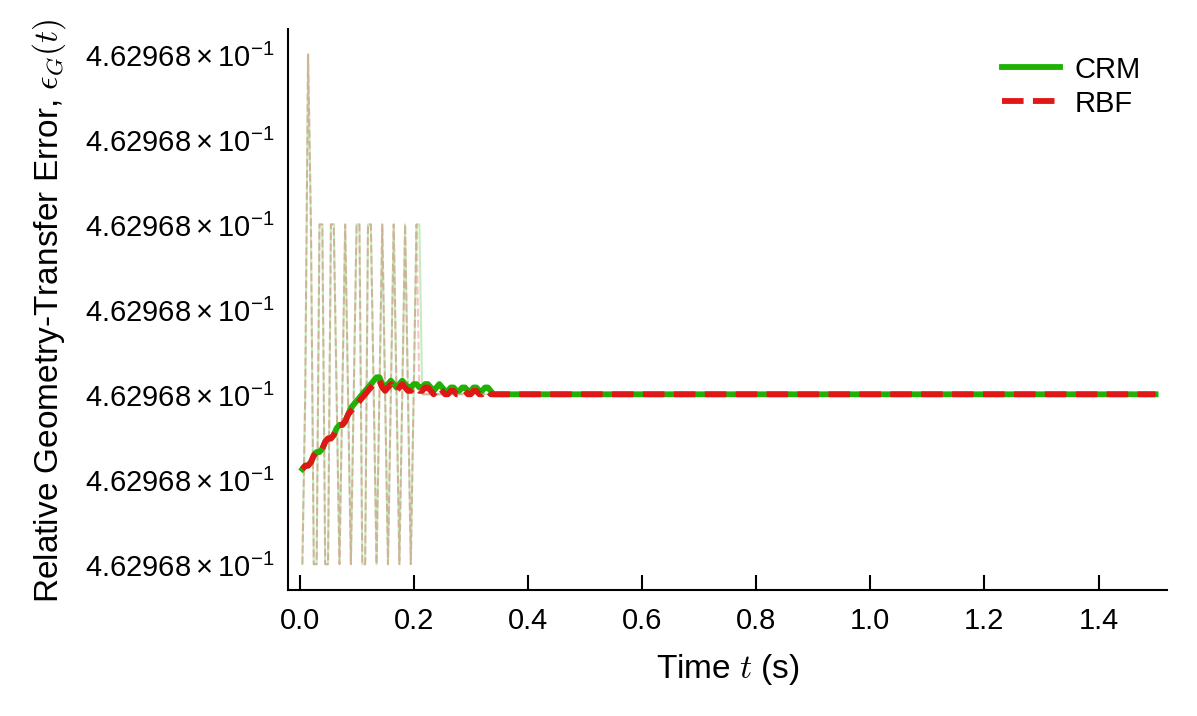

In [7]:
# ============================================================
# FIGURE 2 — Relative Geometry-Transfer Error
# ============================================================

fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)
ax.set_yscale("log")

# ------------------------------------------------------------
# Raw geometry-transfer errors
# ------------------------------------------------------------

ax.plot(
    time_coupling_crm,
    crm_geometry_error,
    color=COLOR_CRM_GEOMETRY,
    linestyle="-",
    linewidth=0.5,
    alpha=0.25,
    zorder=1
)

ax.plot(
    time_coupling_rbf,
    rbf_geometry_error,
    color=COLOR_RBF_GEOMETRY,
    linestyle="--",
    linewidth=0.5,
    alpha=0.25,
    zorder=1
)

# ------------------------------------------------------------
# Moving-average geometry-transfer errors
# ------------------------------------------------------------

h_crm, = ax.plot(
    time_coupling_crm,
    crm_geometry_ma,
    color=COLOR_CRM_GEOMETRY,
    linestyle="-",
    linewidth=1.4,
    alpha=1.0,
    zorder=2
)

h_rbf, = ax.plot(
    time_coupling_rbf,
    rbf_geometry_ma,
    color=COLOR_RBF_GEOMETRY,
    linestyle="--",
    linewidth=1.4,
    alpha=1.0,
    zorder=2
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    r"Time $t$ (s)",
    labelpad=4
)

ax.set_ylabel(
    r"Relative Geometry-Transfer Error, $\epsilon_G(t)$",
    labelpad=4
)

ax.set_xlim(-0.02, 1.52)

ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4])

ax.tick_params(
    axis="both",
    which="major",
    length=3.5,
    pad=4
)

ax.tick_params(
    axis="y",
    which="minor",
    length=2.0,
    left=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.legend(
    handles=[h_crm, h_rbf],
    labels=["CRM", "RBF"],
    frameon=False,
    loc="upper right",
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=0.5
)

fig.tight_layout()

fig.savefig(
    fig_dir / "relative_geometry_transfer_error.pdf",
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [8]:
# import matplotlib.pyplot as plt
# from pathlib import Path

# # --- 1. Nature Journal Global Style Configuration ---
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
#     "font.size": 7,
#     "axes.labelsize": 8,
#     "axes.titlesize": 8,
#     "legend.fontsize": 7,
#     "xtick.labelsize": 7,
#     "ytick.labelsize": 7,
#     "axes.linewidth": 0.5,
#     "xtick.major.width": 0.5,
#     "ytick.major.width": 0.5,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42
# })

# # --- Color Palette Assignment ---
# COLOR_CRM = "#A01717"
# COLOR_RBF = "#1C417D"

# # --- 2. Convert Coupling Step to Physical Time ---
# time_coupling_crm = diagnostic_time(fluid_coupling_crm, solid_crm)
# time_coupling_rbf = diagnostic_time(fluid_coupling_rbf, solid_rbf)

# # --- 3. Setup Figure ---
# fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)

# # --- 4. Plot FSI Residuals Against Physical Time ---

# h_crm_f, = ax.semilogy(
#     time_coupling_crm,
#     fluid_coupling_crm["force_residual"],
#     color=COLOR_CRM,
#     linestyle="-",
#     linewidth=0.8,
#     alpha=1.0
# )

# h_crm_g, = ax.semilogy(
#     time_coupling_crm,
#     fluid_coupling_crm["geometry_residual"],
#     color=COLOR_CRM,
#     linestyle="-",
#     linewidth=0.8,
#     alpha=0.6
# )

# h_rbf_f, = ax.semilogy(
#     time_coupling_rbf,
#     fluid_coupling_rbf["force_residual"],
#     color=COLOR_RBF,
#     linestyle="--",
#     linewidth=0.8,
#     alpha=1.0
# )

# h_rbf_g, = ax.semilogy(
#     time_coupling_rbf,
#     fluid_coupling_rbf["geometry_residual"],
#     color=COLOR_RBF,
#     linestyle="--",
#     linewidth=0.8,
#     alpha=0.6
# )

# # --- 5. Axes ---
# ax.set_xlabel("Time (s)", labelpad=4)
# ax.set_ylabel("Residual (Log Scale)", labelpad=4)


# ax.tick_params(
#     axis="both",
#     which="major",
#     length=3.5,
#     pad=4
# )

# ax.tick_params(
#     axis="y",
#     which="minor",
#     length=2.0,
#     left=False
# )

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# ax.grid(False)

# # --- 6. Legend ---
# ax.legend(
#     handles=[
#         h_crm_f,
#         h_crm_g,
#         h_rbf_f,
#         h_rbf_g
#     ],
#     labels=[
#         "CRM Force",
#         "CRM Geometry",
#         "RBF Force",
#         "RBF Geometry"
#     ],
#     frameon=False,
#     loc="upper right",
#     handletextpad=0.5,
#     labelspacing=0.2,
#     borderaxespad=0.5
# )

# # --- 7. Export ---
# fig.tight_layout()

# fig_dir = Path(FIG_DIR) if "FIG_DIR" in locals() else Path(".")

# fig.savefig(
#     fig_dir / "fsi_coupling_residuals.pdf",
#     bbox_inches="tight",
#     transparent=True
# )

# plt.show()


In [9]:
# print("CRM:", len(steps_crm), steps_crm[0], steps_crm[-1],
#       "t_end =", time_coupling_crm[-1])

# print("RBF:", len(steps_rbf), steps_rbf[0], steps_rbf[-1],
#       "t_end =", time_coupling_rbf[-1])


In [10]:
# TRANSFER_COLUMNS = [
#     "force_transfer_relative_error",
#     "geometry_transfer_relative_error",
# ]
# require_columns(coupling_crm, TRANSFER_COLUMNS, "CRM coupling_history.csv")
# require_columns(coupling_rbf, TRANSFER_COLUMNS, "RBF coupling_history.csv")

# def moving_average(data, window_size=50):
#     data = np.asarray(data, dtype=float)

#     if window_size <= 1:
#         return data.copy()

#     window_size = min(window_size, len(data))

#     pad_left = window_size // 2
#     pad_right = window_size - 1 - pad_left

#     padded = np.pad(
#         data,
#         (pad_left, pad_right),
#         mode="edge"
#     )

#     kernel = np.ones(window_size) / window_size

#     return np.convolve(padded, kernel, mode="valid")


# time_coupling_crm = coupling_crm["time"].to_numpy(dtype=float)
# time_coupling_rbf = coupling_rbf["time"].to_numpy(dtype=float)

# WINDOW = 50

# crm_f_ma = moving_average(
#     coupling_crm["force_transfer_relative_error"].to_numpy(dtype=float),
#     WINDOW
# )

# crm_g_ma = moving_average(
#     coupling_crm["geometry_transfer_relative_error"].to_numpy(dtype=float),
#     WINDOW
# )

# rbf_f_ma = moving_average(
#     coupling_rbf["force_transfer_relative_error"].to_numpy(dtype=float),
#     WINDOW
# )

# rbf_g_ma = moving_average(
#     coupling_rbf["geometry_transfer_relative_error"].to_numpy(dtype=float),
#     WINDOW
# )


# fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)
# ax.set_yscale("log")

# ax.plot(
#     time_coupling_crm,
#     coupling_crm["force_transfer_relative_error"],
#     color=COLOR_CRM_FORCE,
#     linestyle="-",
#     linewidth=0.4,
#     alpha=0.15
# )

# ax.plot(
#     time_coupling_rbf,
#     coupling_rbf["force_transfer_relative_error"],
#     color=COLOR_RBF_FORCE,
#     linestyle="--",
#     linewidth=0.4,
#     alpha=0.15
# )

# h_crm, = ax.plot(
#     time_coupling_crm,
#     crm_f_ma,
#     color=COLOR_CRM_FORCE,
#     linestyle="-",
#     linewidth=1.4
# )

# h_rbf, = ax.plot(
#     time_coupling_rbf,
#     rbf_f_ma,
#     color=COLOR_RBF_FORCE,
#     linestyle="--",
#     linewidth=1.4
# )

# ax.set_xlabel("Time t (s)", labelpad=4)
# ax.set_ylabel("Relative Force-Transfer Error,$\quad \epsilon_F(t)$", labelpad=4)

# ax.set_xlim(-0.02, 1.52)

# ax.tick_params(axis="both", which="major", length=3.5, pad=4)
# ax.tick_params(axis="y", which="minor", length=2.0, left=False)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.grid(False)

# ax.legend(
#     handles=[h_crm, h_rbf],
#     labels=["CRM", "RBF"],
#     frameon=False,
#     loc="upper right",
#     handletextpad=0.5,
#     labelspacing=0.2,
#     borderaxespad=0.5
# )

# fig.tight_layout()

# fig.savefig(
#     fig_dir / "relative_force_transfer_error.pdf",
#     bbox_inches="tight",
#     transparent=True
# )

# plt.show()



In [11]:
# fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)
# ax.set_yscale("log")

# ax.plot(
#     time_coupling_crm,
#     coupling_crm["geometry_transfer_relative_error"],
#     color=COLOR_CRM_GEOMETRY,
#     linestyle="-",
#     linewidth=0.4,
#     alpha=0.15
# )

# ax.plot(
#     time_coupling_rbf,
#     coupling_rbf["geometry_transfer_relative_error"],
#     color=COLOR_RBF_GEOMETRY,
#     linestyle="--",
#     linewidth=0.4,
#     alpha=0.15
# )

# h_crm, = ax.plot(
#     time_coupling_crm,
#     crm_g_ma,
#     color=COLOR_CRM_GEOMETRY,
#     linestyle="-",
#     linewidth=1.4
# )

# h_rbf, = ax.plot(
#     time_coupling_rbf,
#     rbf_g_ma,
#     color=COLOR_RBF_GEOMETRY,
#     linestyle="--",
#     linewidth=1.4
# )

# ax.set_xlabel("Time t (s)", labelpad=4)
# ax.set_ylabel("Relative Geometry-Transfer Error,$\quad \epsilon_G(t)$", labelpad=4)

# ax.set_xlim(-0.02, 1.52)

# ax.tick_params(axis="both", which="major", length=3.5, pad=4)
# ax.tick_params(axis="y", which="minor", length=2.0, left=False)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.grid(False)

# ax.legend(
#     handles=[h_crm, h_rbf],
#     labels=["CRM", "RBF"],
#     frameon=False,
#     loc="upper right",
#     handletextpad=0.5,
#     labelspacing=0.2,
#     borderaxespad=0.5
# )

# fig.tight_layout()

# fig.savefig(
#     fig_dir / "relative_geometry_transfer_error.pdf",
#     bbox_inches="tight",
#     transparent=True
# )

# plt.show()
